In [4]:
# --- Cell 1: imports + config ---
%load_ext autoreload
%autoreload 2
import sys, torch, numpy as np
sys.path.append('..')
sys.path.append('../..')

from common.seed import set_seed
from common.io_utils import save_results, load_results
from shared.pacs_protocol import build_loaders
from task2.backbones.backbone import PACSModel          # identical architecture
from task2.training.train_loop import train_model       # identical pipeline
from task3.methods.dan_dg import DAN_DG

set_seed(6304)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CFG = dict(seed=6304, num_classes=7,
           batch_per_source=8, target_batch=24, eval_batch=64, num_workers=0,
           max_epochs=30, patience=5, lr=1e-4, weight_decay=1e-4, amp=False,
           lambda_dg=1.0)
DATA_ROOT = '../../datasets/PACS'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# --- Cell 2: loaders WITHOUT the target domain ---
splits = load_results('../../shared/splits/pacs_sketch_seed6304.json')
loaders = build_loaders(DATA_ROOT, splits,
                        batch_per_source=CFG['batch_per_source'],
                        eval_batch=CFG['eval_batch'],
                        num_workers=CFG['num_workers'], seed=CFG['seed'],
                        include_target=False)
assert loaders['target_train'] is None and loaders['target_eval'] is None
print(f"source train={loaders['n_source_train']}  steps/epoch={loaders['steps_per_epoch']}  "
      f"target loaders={loaders['n_target']} (must be 0)")

source train=4849  steps/epoch=203  target loaders=0 (must be 0)


In [6]:
# --- Cell 3: VERIFICATION —  ---
from shared.pacs_protocol import next_source_batch
x, y = next_source_batch(loaders['source_train'], device)
print('batch shape', tuple(x.shape), '(expect 24 x 3 x 224 x 224)')
print('per-domain block labels:', [y[i*8:(i+1)*8].tolist() for i in range(3)])


batch shape (24, 3, 224, 224) (expect 24 x 3 x 224 x 224)
per-domain block labels: [[3, 5, 3, 6, 0, 5, 6, 6], [6, 6, 6, 6, 5, 2, 2, 5], [6, 1, 2, 5, 3, 1, 6, 5]]


In [9]:
# --- Cell 3b: is the MMD term swamping classification, or is something else wrong? ---
from shared.pacs_protocol import next_source_batch
from task2.backbones.backbone import set_train_mode, PACSModel
from task3.methods.dan_dg import DAN_DG
import torch

set_seed(6304)
probe = PACSModel(num_classes=7).to(device)
pm = DAN_DG(CFG)
opt = torch.optim.AdamW(probe.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
set_train_mode(probe)

for step in range(60):
    sx, sy = next_source_batch(loaders['source_train'], device)
    opt.zero_grad(set_to_none=True)
    loss, logs = pm.compute_loss(probe, sx, sy, None, 0.0)
    # measure the two gradient contributions separately
    gc = torch.autograd.grad(torch.nn.functional.cross_entropy(probe(sx)[0], sy),
                             list(probe.parameters()), retain_graph=False,
                             allow_unused=True)
    gc_norm = torch.sqrt(sum((g**2).sum() for g in gc if g is not None)).item()
    loss.backward(); opt.step()
    if step % 10 == 0:
        with torch.no_grad():
            fn = probe(sx)[1].norm(dim=1).mean().item()
        print(f"step {step:3d} cls={logs['loss_cls']:.3f} mmd={logs['loss_mmd']:.3f} "
              f"acc={logs['train_acc']:.3f} |f|={fn:6.1f} |grad_cls|={gc_norm:.2f}")
del probe, opt; torch.cuda.empty_cache()

step   0 cls=2.323 mmd=0.807 acc=0.125 |f|=  19.2 |grad_cls|=14.45
step  10 cls=1.891 mmd=0.600 acc=0.417 |f|=   4.7 |grad_cls|=2.99
step  20 cls=1.944 mmd=0.884 acc=0.125 |f|=   5.6 |grad_cls|=1.92
step  30 cls=1.976 mmd=0.581 acc=0.000 |f|=   5.2 |grad_cls|=2.08
step  40 cls=1.959 mmd=0.951 acc=0.125 |f|=   4.6 |grad_cls|=1.00
step  50 cls=1.924 mmd=0.624 acc=0.167 |f|=   3.7 |grad_cls|=1.61


In [ ]:
# --- Cell 3c: DIAGNOSTIC — trainability at the sweep's lower lambda (source data only) ---
set_seed(6304)
probe = PACSModel(num_classes=7).to(device)
pm = DAN_DG(dict(CFG, lambda_dg=0.1))          # the only change
opt = torch.optim.AdamW(probe.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
set_train_mode(probe)

for step in range(60):
    sx, sy = next_source_batch(loaders['source_train'], device)
    opt.zero_grad(set_to_none=True)
    loss, logs = pm.compute_loss(probe, sx, sy, None, 0.0)
    loss.backward(); opt.step()
    if step % 10 == 0:
        with torch.no_grad():
            fn = probe(sx)[1].norm(dim=1).mean().item()
        print(f"step {step:3d} cls={logs['loss_cls']:.3f} mmd={logs['loss_mmd']:.3f} "
              f"acc={logs['train_acc']:.3f} |f|={fn:6.1f}")
del probe, opt; torch.cuda.empty_cache()

step   0 cls=2.030 mmd=0.669 acc=0.208 |f|=  25.0
step  10 cls=1.239 mmd=0.686 acc=0.625 |f|=  25.5
step  20 cls=0.954 mmd=0.766 acc=0.750 |f|=  31.4
step  30 cls=0.580 mmd=0.619 acc=0.792 |f|=  39.4
step  40 cls=0.858 mmd=0.525 acc=0.750 |f|=  44.6
step  50 cls=0.473 mmd=0.691 acc=0.792 |f|=  43.2


In [7]:
# --- Cell 4: train DAN-DG ---
set_seed(6304)
loaders = build_loaders(DATA_ROOT, splits,              # rebuild: fixed sampling order
                        batch_per_source=CFG['batch_per_source'],
                        eval_batch=CFG['eval_batch'],
                        num_workers=CFG['num_workers'], seed=CFG['seed'],
                        include_target=False)
model = PACSModel(num_classes=CFG['num_classes']).to(device)
method = DAN_DG(CFG)

out = train_model(model, method, loaders, CFG, device,
                  ckpt_path='../../datasets/cache/task3_dan_dg.pt')
print(out['best_epoch'], out['best_mean_macro_f1'], f"{out['minutes']:.1f} min")

ep01 loss_total=2.5175 loss_cls=1.9415 loss_mmd=0.5760 mmd_pa=0.5180 mmd_pc=0.5934 mmd_ac=0.6166 train_acc=0.2042 | val photo=0.059 art_painting=0.051 cartoon=0.042 mean_f1=0.0507 | 31s
ep02 loss_total=2.4777 loss_cls=1.9380 loss_mmd=0.5396 mmd_pa=0.5077 mmd_pc=0.5801 mmd_ac=0.5310 train_acc=0.2128 | val photo=0.059 art_painting=0.051 cartoon=0.042 mean_f1=0.0507 | 64s
ep03 loss_total=2.4706 loss_cls=1.9284 loss_mmd=0.5422 mmd_pa=0.4873 mmd_pc=0.5946 mmd_ac=0.5446 train_acc=0.1979 | val photo=0.059 art_painting=0.051 cartoon=0.042 mean_f1=0.0507 | 90s
ep04 loss_total=2.4366 loss_cls=1.9361 loss_mmd=0.5005 mmd_pa=0.4602 mmd_pc=0.5454 mmd_ac=0.4961 train_acc=0.2096 | val photo=0.059 art_painting=0.051 cartoon=0.042 mean_f1=0.0507 | 114s
ep05 loss_total=2.4808 loss_cls=1.9363 loss_mmd=0.5445 mmd_pa=0.5139 mmd_pc=0.5730 mmd_ac=0.5467 train_acc=0.1927 | val photo=0.041 art_painting=0.036 cartoon=0.031 mean_f1=0.0361 | 139s
ep06 loss_total=2.4578 loss_cls=1.9293 loss_mmd=0.5285 mmd_pa=0.4856

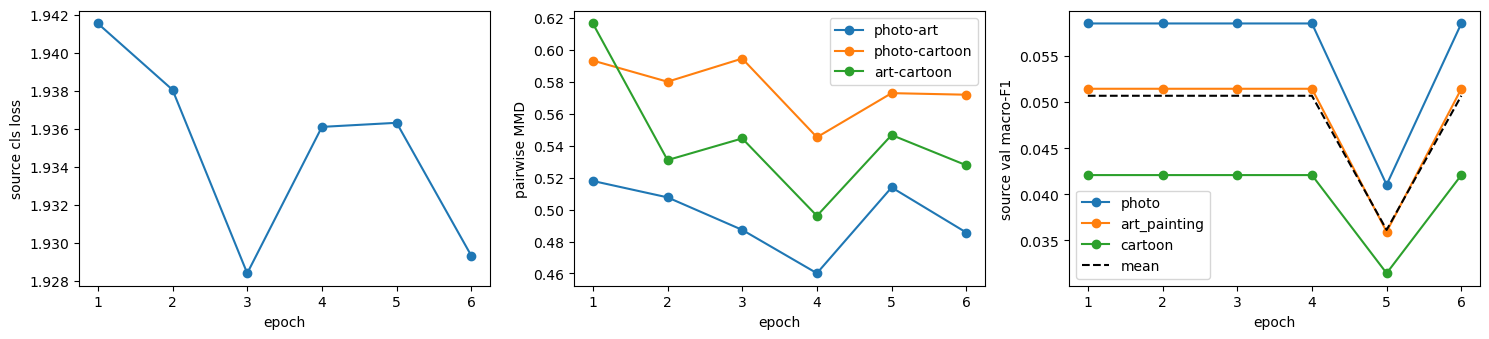

In [10]:
# --- Cell 5: save + curves ---
results = {'step': 'dan_dg', 'seed': 6304, 'method': 'dan_dg', 'config': CFG,
           'steps_per_epoch': loaders['steps_per_epoch'],
           'best_epoch': out['best_epoch'],
           'best_mean_macro_f1': out['best_mean_macro_f1'],
           'source_val_at_best': out['source_val_at_best'],
           'minutes': out['minutes'], 'history': out['history']}
save_results(results, '../results/dan_dg.json')

import matplotlib.pyplot as plt
h = out['history']; ep = [r['epoch'] for r in h]
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
ax[0].plot(ep, [r['loss_cls'] for r in h], marker='o'); ax[0].set_ylabel('source cls loss')
for k, lab in [('mmd_pa', 'photo-art'), ('mmd_pc', 'photo-cartoon'), ('mmd_ac', 'art-cartoon')]:
    ax[1].plot(ep, [r[k] for r in h], marker='o', label=lab)
ax[1].set_ylabel('pairwise MMD'); ax[1].legend()
for d_ in splits['source_domains']:
    ax[2].plot(ep, [r['per_domain'][d_]['macro_f1'] for r in h], marker='o', label=d_)
ax[2].plot(ep, [r['mean_macro_f1'] for r in h], 'k--', label='mean')
ax[2].set_ylabel('source val macro-F1'); ax[2].legend()
for a in ax: a.set_xlabel('epoch')
plt.tight_layout(); plt.savefig('../../report/figures/task3_dan_dg_curves.png', dpi=200)
plt.show()